# Experiments Guide

## 0. Colab Setup

In [ ]:
!git clone -b dev-hubert https://github.com/luigiaceto/explainable-models-for-speech-analysis.git
%cd explainable-models-for-speech-analysis
%pip install -r requirements-colab.txt

## 1. Project Setup

In [7]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.audio_features import pooled_feature_dim
from src.utils.naming import blackbox_run_dir_name, model_name_to_slug, pooled_feature_dir_name

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw" / "crema_d"
AUDIO_DIR = RAW_DIR / "AudioWAV"

# (model_name, dimension_of_the_original_vectors_generated_by_the_model)
FEATURE_EXTRACTOR = ("microsoft/wavlm-large", 1024)

FEATURE_EXTRACTOR_NAME, ENCODER_EMBEDDING_DIM = FEATURE_EXTRACTOR
FEATURE_EXTRACTOR_ID = model_name_to_slug(FEATURE_EXTRACTOR_NAME)
FEATURE_POOLING = "mean_std"
FEATURE_DIM = pooled_feature_dim(ENCODER_EMBEDDING_DIM, FEATURE_POOLING)

FEATURE_DIR = DATA_DIR / "features" / pooled_feature_dir_name(FEATURE_EXTRACTOR_NAME, FEATURE_POOLING)
BLACK_BOX_CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints" / blackbox_run_dir_name(FEATURE_EXTRACTOR_NAME)
BLACK_BOX_REPORT_DIR = PROJECT_ROOT / "reports" / blackbox_run_dir_name(FEATURE_EXTRACTOR_NAME)

FEATURE_EXTRACTION_BATCH_SIZE = 8
FEATURE_EXTRACTION_NUM_WORKERS = 0
RANDOM_STATE = 42

PROJECT_ROOT

PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis')

## 2. Download CREMA-D

In [8]:
from src.preprocessing.download_crema_d import download_crema_d

metadata = download_crema_d(
    output_dir=RAW_DIR,
    overwrite=False
)

metadata.head(n=10)

,file_name,actor_id,sentence_code,sentence,emotion_code,emotion,label,intensity_code,intensity,audio_path
0,1001_DFA_ANG_XX.wav,1001,DFA,Don't forget a jacket,ANG,anger,0,XX,unspecified,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...
1,1001_DFA_DIS_XX.wav,1001,DFA,Don't forget a jacket,DIS,disgust,1,XX,unspecified,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...
2,1001_DFA_FEA_XX.wav,1001,DFA,Don't forget a jacket,FEA,fear,2,XX,unspecified,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...
3,1001_DFA_HAP_XX.wav,1001,DFA,Don't forget a jacket,HAP,happy,3,XX,unspecified,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...
4,1001_DFA_NEU_XX.wav,1001,DFA,Don't forget a jacket,NEU,neutral,4,XX,unspecified,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...
5,1001_DFA_SAD_XX.wav,1001,DFA,Don't forget a jacket,SAD,sad,5,XX,unspecified,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...
6,1001_IEO_ANG_HI.wav,1001,IEO,It's eleven o'clock,ANG,anger,0,HI,high,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...
7,1001_IEO_ANG_LO.wav,1001,IEO,It's eleven o'clock,ANG,anger,0,LO,low,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...
8,1001_IEO_ANG_MD.wav,1001,IEO,It's eleven o'clock,ANG,anger,0,MD,medium,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...
9,1001_IEO_DIS_HI.wav,1001,IEO,It's eleven o'clock,DIS,disgust,1,HI,high,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...


## 3. Dataset Statistics

In [9]:
from src.data.crema_d import print_dataset_statistics

print_dataset_statistics(metadata)

Total samples: 7442
Actors: 91
Sentence prompts: 12

Samples per emotion:
emotion  sample_count  percentage
  anger          1271   17.078742
disgust          1271   17.078742
   fear          1271   17.078742
  happy          1271   17.078742
neutral          1087   14.606289
    sad          1271   17.078742


## 4. Extract Frozen Audio Encoder Features

In [10]:
from src.preprocessing.extract_audio_features import extract_audio_features

feature_paths = extract_audio_features(
    metadata_csv=RAW_DIR / "metadata.csv",
    audio_dir=AUDIO_DIR,
    output_dir=FEATURE_DIR,
    model_name=FEATURE_EXTRACTOR_NAME,
    expected_encoder_embedding_dim=ENCODER_EMBEDDING_DIM,
    pooling=FEATURE_POOLING,
    batch_size=FEATURE_EXTRACTION_BATCH_SIZE,
    num_workers=FEATURE_EXTRACTION_NUM_WORKERS,
    overwrite=False
)

feature_paths

{'features': PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis/data/features/wavlm_large_mean_std/features.npy'),
 'metadata': PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis/data/features/wavlm_large_mean_std/metadata.csv'),
 'config': PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis/data/features/wavlm_large_mean_std/feature_config.json')}

## 5. Train the Black-Box Classifier

In [11]:
from src.training.train_blackbox import TrainingConfig, train_blackbox

SPLIT_STRATEGY = "sample_stratified"
#SPLIT_STRATEGY = "speaker_independent" # each split has different voice actors

training_config = TrainingConfig(
    input_dim=FEATURE_DIM,
    feature_extractor_name=FEATURE_EXTRACTOR_NAME,
    encoder_embedding_dim=ENCODER_EMBEDDING_DIM,
    pooling=FEATURE_POOLING,
    hidden_dims=(256, 128),
    batch_size=64,
    epochs=100,
    dropout=0.25,
    learning_rate=2e-4,
    weight_decay=5e-4,
    split_strategy=SPLIT_STRATEGY,
    speaker_column="actor_id",
    early_stopping_patience=15,
    #lr_scheduler=None, # by default the scheduler is active. Need to set it explicitly to None if we wanna turn it off
    scheduler_patience=6,
    random_state=RANDOM_STATE
)

training_results = train_blackbox(
    feature_dir=FEATURE_DIR,
    output_dir=BLACK_BOX_CHECKPOINT_DIR,
    config=training_config
)

Training black-box model:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 001 | train loss 1.6305, acc 0.3225, macro F1 0.3033 | val loss 1.4518, acc 0.4839, macro F1 0.4326, weighted F1 0.4295 | lr 2.00e-04 | best
Epoch 002 | train loss 1.4176, acc 0.4579, macro F1 0.4411 | val loss 1.3603, acc 0.4901, macro F1 0.4631, weighted F1 0.4601 | lr 2.00e-04 | best
Epoch 003 | train loss 1.2783, acc 0.5337, macro F1 0.5239 | val loss 1.1643, acc 0.5995, macro F1 0.5822, weighted F1 0.5789 | lr 2.00e-04 | best
Epoch 004 | train loss 1.1821, acc 0.5729, macro F1 0.5681 | val loss 1.1699, acc 0.5771, macro F1 0.5507, weighted F1 0.5475 | lr 2.00e-04 | patience 1/15
Epoch 005 | train loss 1.1317, acc 0.6065, macro F1 0.6037 | val loss 1.0867, acc 0.6487, macro F1 0.6550, weighted F1 0.6508 | lr 2.00e-04 | best
Epoch 006 | train loss 1.0963, acc 0.6170, macro F1 0.6149 | val loss 1.0698, acc 0.6496, macro F1 0.6503, weighted F1 0.6462 | lr 2.00e-04 | patience 1/15
Epoch 007 | train loss 1.0424, acc 0.6462, macro F1 0.6449 | val loss 1.0398, acc 0.6470, macro F1 0

## 6. Evaluate the Black-Box Classifier

In [12]:
from src.evaluation.evaluate_blackbox import evaluate_blackbox, print_classification_metrics

test_metrics = evaluate_blackbox(
    checkpoint_path=BLACK_BOX_CHECKPOINT_DIR / "best_model.pt",
    feature_dir=FEATURE_DIR,
    splits_csv=BLACK_BOX_CHECKPOINT_DIR / "splits.csv",
    split="test",
    output_dir=BLACK_BOX_REPORT_DIR
)

print_classification_metrics(test_metrics)

Accuracy:    0.7699
Macro F1:    0.7721
Weighted F1: 0.7701

Classification report:
emotion precision recall f1_score  support
  anger    0.8710 0.8482   0.8594      191
disgust    0.7457 0.6754   0.7088      191
   fear    0.7391 0.7158   0.7273      190
  happy    0.7760 0.7435   0.7594      191
neutral    0.8485 0.8589   0.8537      163
    sad    0.6681 0.7906   0.7242      191


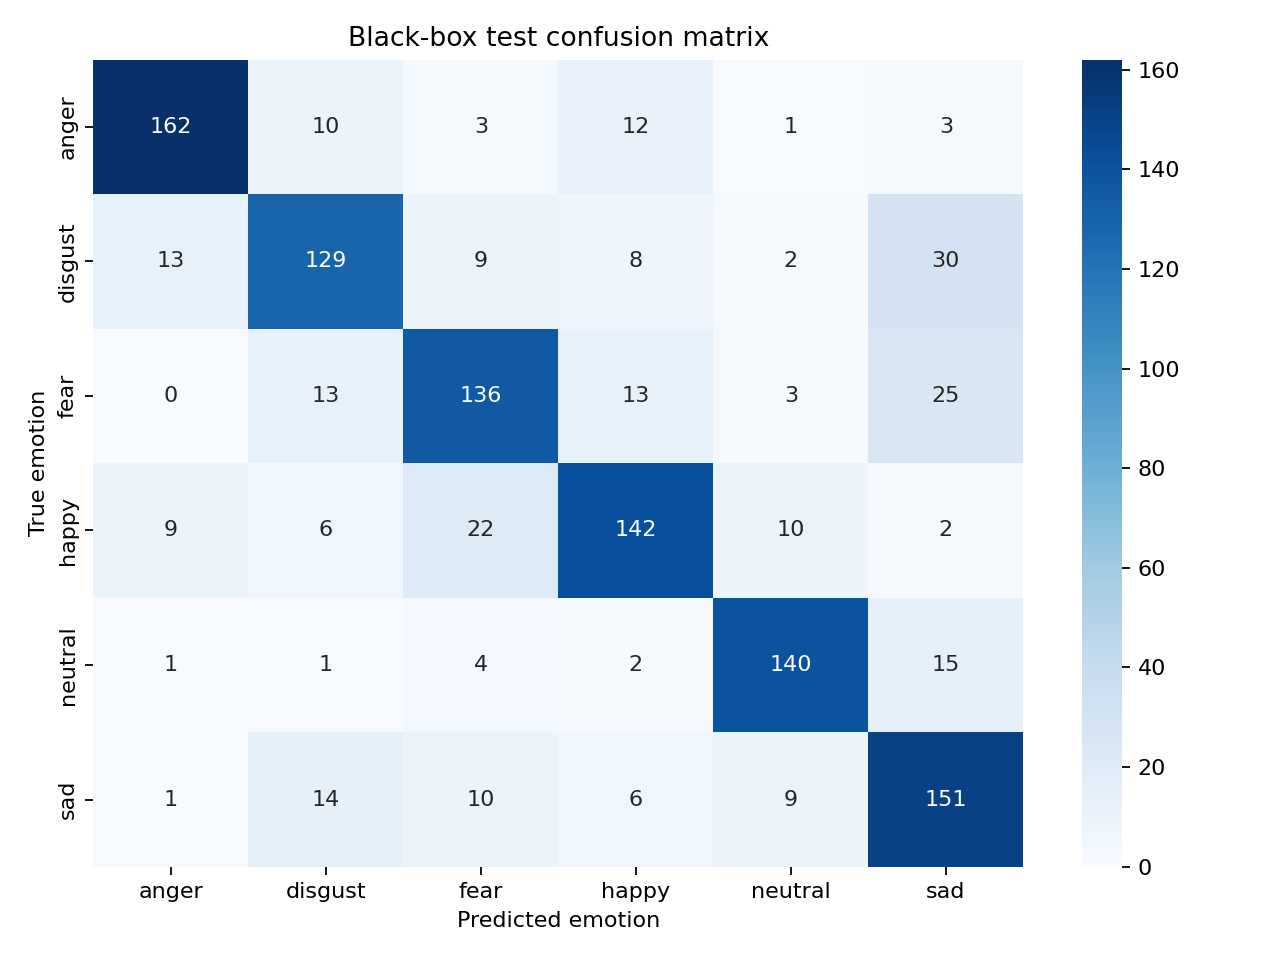

In [13]:
from IPython.display import Image, display

confusion_matrix_path = BLACK_BOX_REPORT_DIR / "test_confusion_matrix.png"
if confusion_matrix_path.exists():
    display(Image(filename=str(confusion_matrix_path)))

## 7. Visualize Embedding Spaces

Project the pooled audio encoder features and the trained black-box penultimate representations to two PCA dimensions.


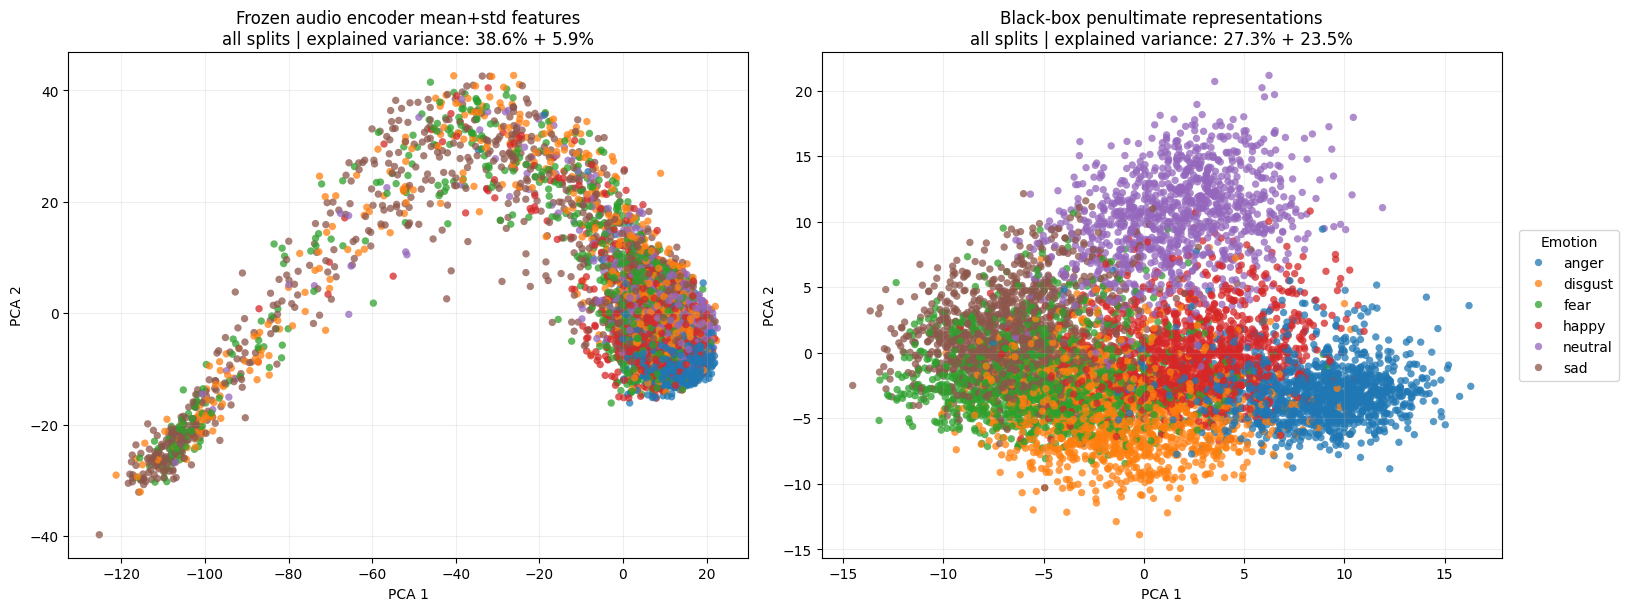

PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis/reports/blackbox_wavlm_large/all_embedding_pca.png')

In [16]:
from src.evaluation.visualize import plot_blackbox_embedding_pca

split_to_visualize = "all"

embedding_pca_result = plot_blackbox_embedding_pca(
    feature_dir=FEATURE_DIR,
    checkpoint_path=BLACK_BOX_CHECKPOINT_DIR / "best_model.pt",
    splits_csv=BLACK_BOX_CHECKPOINT_DIR / "splits.csv",
    split=split_to_visualize,
    output_path=BLACK_BOX_REPORT_DIR / f"{split_to_visualize}_embedding_pca.png",
    random_state=RANDOM_STATE
)
embedding_pca_result["output_path"]